In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import seaborn as sns

In [2]:
# Load data (stored next to this notebook)
df = pd.read_csv('advertising.csv', index_col=0)
print(f'{df.shape[0]} samples')
print(f'{df.shape[1]-1} features')
df.head()

200 samples
3 features


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## Split X and y

In [3]:
X = df.drop('Sales', axis='columns')
y = df['Sales']
X.head(2), y.head(2)

(      TV  Radio  Newspaper
 1  230.1   37.8       69.2
 2   44.5   39.3       45.1,
 1    22.1
 2    10.4
 Name: Sales, dtype: float64)

## 1. Train|test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((140, 3), (60, 3), (140,), (60,))

## 2. Feature scaling (MinMax)
Normalization: $X' = (X - X_{min})/(X_{max} - X_{min})$.

In [5]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled[:3]

array([[0.95908015, 0.21370968, 0.06063618],
       [0.62292864, 0.4233871 , 0.21570577],
       [0.37943862, 0.35080645, 0.38071571]])

## 3. Fit LinearRegression

In [6]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
coefs = model.coef_
intercept = model.intercept_
coefs, intercept

(array([13.02832938,  9.88465985,  0.69237469]),
 np.float64(2.7418553248528124))

## 4. Evaluate (MAE, MSE, RMSE, R²)

In [7]:
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f'MAE: {mae:.3f}  MSE: {mse:.3f}  RMSE: {rmse:.3f}  R2: {r2:.3f}')

MAE: 1.512  MSE: 3.797  RMSE: 1.949  R2: 0.861


## 5. Plot predictions vs truth

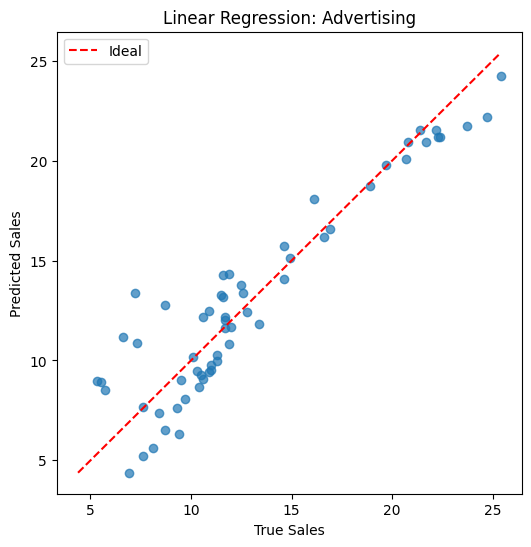

In [8]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
vmin, vmax = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([vmin, vmax], [vmin, vmax], 'r--', label='Ideal')
plt.xlabel('True Sales')
plt.ylabel('Predicted Sales')
plt.title('Linear Regression: Advertising')
plt.legend()
plt.show()

## 6. Residual diagnostics

Residuals: mean= -0.03848895253439652  std= 1.9645974713207863


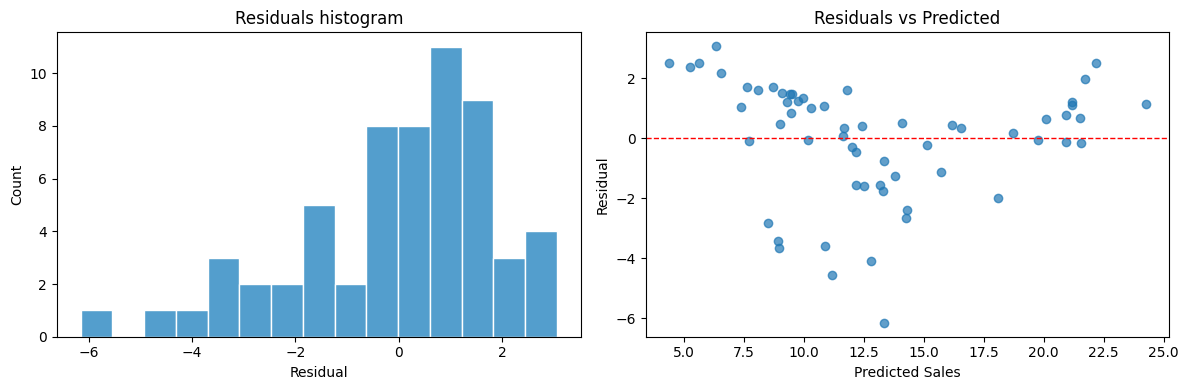

In [8]:
# Residuals: true - predicted
residuals = y_test - y_pred
print('Residuals: mean=', float(residuals.mean()), ' std=', float(residuals.std()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(residuals, bins=15, color='#539ecd', edgecolor='white')
axes[0].set_title('Residuals histogram')
axes[0].set_xlabel('Residual'); axes[0].set_ylabel('Count')
axes[1].scatter(y_pred, residuals, alpha=0.7)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Sales'); axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.show()

## 7. Pairplot (EDA)

In [11]:
# Quick pairplot for the dataset (features + target)
sns.pairplot(df, diag_kind='kde', corner=True)
plt.show()

NameError: name 'sns' is not defined

## 8. Coefficients bar chart

In [ ]:
feature_names = list(X.columns)
coef_values = model.coef_
plt.figure(figsize=(6,4))
bars = plt.bar(feature_names, coef_values, color='#6aa84f')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients')
plt.ylabel('Coefficient value')
plt.tight_layout()
plt.show()